In [ ]:
#import your libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

In [ ]:
# import datasheet
url = (r'https://raw.githubusercontent.com/Ali-Aryo/PhishNet.AI/refs/heads/main/Dataset/SpamAssasin.csv')

df = pd.read_csv(url)

In [ ]:
# data frame init
df
df.describe()

,label,urls
count,5809.000000,5809.000000
mean,0.295748,0.861078
std,0.456418,0.345895
min,0.000000,0.000000
25%,0.000000,1.000000
50%,0.000000,1.000000
75%,1.000000,1.000000
max,1.000000,1.000000


In [ ]:
# Drop reciever column and remove null rows
df = df.drop('receiver', axis=1)
df = df.dropna(subset=['body', 'subject'])
print("DataFrame after removing 'receiver' column and rows with missing 'body' or 'subject':")
#display(df.head())
print("\nMissing values after cleaning:")
print(df.isnull().sum())

DataFrame after removing 'receiver' column and rows with missing 'body' or 'subject':

Missing values after cleaning:
sender     0
date       0
subject    0
body       0
label      0
urls       0
dtype: int64


In [ ]:
# import for vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
#clean up dataset
import nltk
from nltk.corpus import stopwords
import re

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Remove stop words
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

df['body_cleaned'] = df['body'].apply(clean_text) ## change column

# Display the first few rows to show the cleaned body
# display(df[['body', 'body_cleaned']].head(20)) #test print statemnts

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
#tfidf vectorizatoin
body_array = df['body_cleaned'].to_numpy()
tfidf = TfidfVectorizer()
transformed_body = tfidf.fit_transform(body_array)

# Calculate the average TF-IDF score for each term across all documents
average_tfidf_scores = transformed_body.mean(axis=0)

# Create a DataFrame with the terms and their average TF-IDF scores
tfidf_df = pd.DataFrame(average_tfidf_scores.T,
                        index=tfidf.get_feature_names_out(),
                        columns=["Average TF-IDF"])

# Sort to find the words with the highest average scores
tfidf_df = tfidf_df.sort_values('Average TF-IDF', ascending=False)

print("--- Average TF-IDF Scores Across All Emails ---")
#print(tfidf_df.head(50)) #  Test print statment
# Ranks most important words and returns average

--- Average TF-IDF Scores Across All Emails ---


In [ ]:
# imports for model training
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.metrics import accuracy_score

In [ ]:
# model training
x = transformed_body
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the SVC Model
# To get the ROC AUC score, you need probability estimates.
# Set probability=True. This will make training a bit slower.
model = SVC(probability=True) # Linear kernel is often a good start for text data

print("Training the model...")
clf = model.fit(X_train, y_train)
print("Training complete.")

# 5. Make Predictions
pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, pred)
print(f"Accuracy: {accuracy:.3f}")

# 6. Calculate the ROC AUC Score
# We need the predicted probabilities for the "positive" class (e.g., spam=1)
auc_score = roc_auc_score(y_test, pred)

print(f"\nROC AUC Score: {auc_score:.4f}")

# 7. (Optional but Recommended) View a full classification report
print("\nClassification Report:")
print(classification_report(y_test, pred))

Training the model...
Training complete.
Accuracy: 0.976

ROC AUC Score: 0.9586

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       821
           1       1.00      0.92      0.96       338

    accuracy                           0.98      1159
   macro avg       0.98      0.96      0.97      1159
weighted avg       0.98      0.98      0.98      1159



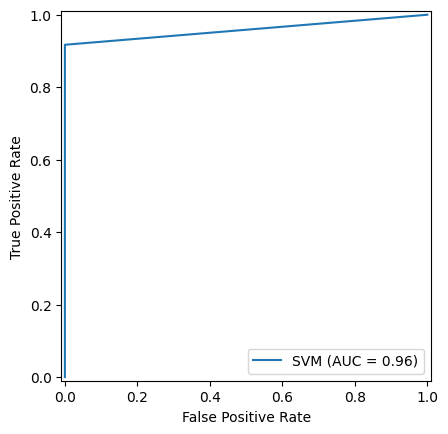

In [ ]:
# Roc graph
from sklearn import metrics
import matplotlib.pyplot as plt
fpr, tpr, thresholds = metrics.roc_curve(y_test, pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,estimator_name='SVM')
display.plot()
plt.show()

In [ ]:
# before underfitting
from collections import Counter
print("Before Undersampling:", Counter(y_train))

Before Undersampling: Counter({0: 3266, 1: 1367})


In [ ]:
# underfitting process
from imblearn.under_sampling import RandomUnderSampler
undersample = RandomUnderSampler(sampling_strategy='majority')

In [ ]:
# after underfitting
X_train_under, y_train_under = undersample.fit_resample(X_train, y_train)
print("After undersampling: ", Counter(y_train_under))

After undersampling:  Counter({0: 1367, 1: 1367})


ROC AUC score for undersampled data:  0.9758971235828727


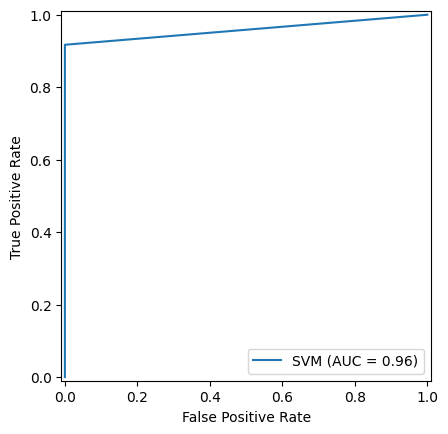

In [ ]:
# Re-train after underfit
model = SVC(probability=True)
clf_under = model.fit(X_train_under, y_train_under)
pred_under = clf_under.predict(X_test)

print("ROC AUC score for undersampled data: ", roc_auc_score(y_test, pred_under))

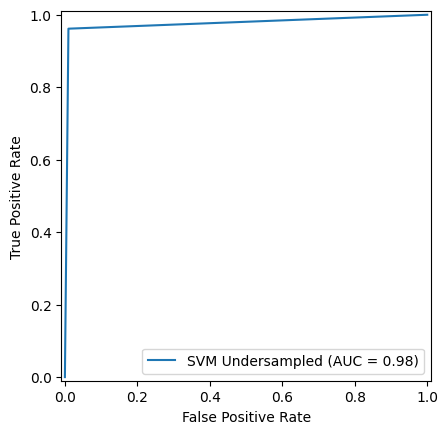

In [ ]:
# Roc curve for undersampled data
from sklearn import metrics
import matplotlib.pyplot as plt
fpr_under, tpr_under, thresholds_under = metrics.roc_curve(y_test, pred_under)
roc_auc_under = metrics.auc(fpr_under, tpr_under)
display_under = metrics.RocCurveDisplay(fpr=fpr_under, tpr=tpr_under, roc_auc=roc_auc_under, estimator_name='SVM Undersampled')
display_under.plot()
plt.show()

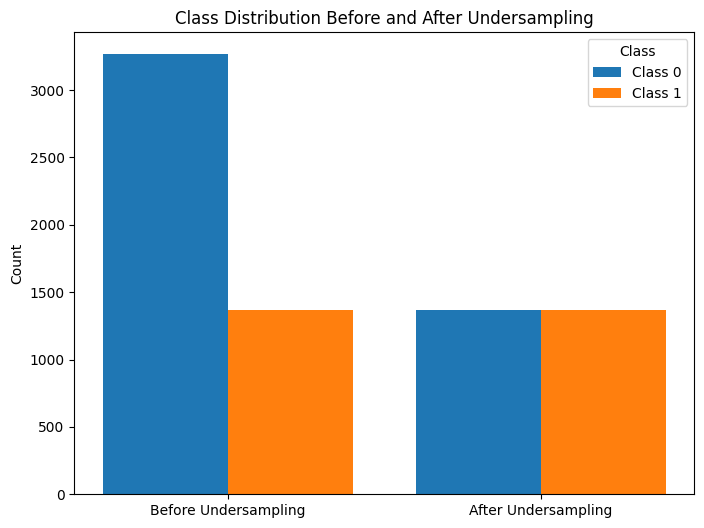

Before Undersampling: Counter({0: 3266, 1: 1367})
After undersampling:  Counter({0: 1367, 1: 1367})


In [ ]:
# Graph comparing counters before and after undersampling
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Undersampling process
undersample = RandomUnderSampler(sampling_strategy='majority')
X_train_under, y_train_under = undersample.fit_resample(X_train, y_train)

# Get counts before and after undersampling
before_counts = Counter(y_train)
after_counts = Counter(y_train_under)

# Prepare data for plotting
labels = sorted(list(before_counts.keys())) # Ensure consistent order
before_values = [before_counts[label] for label in labels]
after_values = [after_counts[label] for label in labels]

x = [0, 1] # Two positions for the two groups: before and after

# Create the bar plot
plt.figure(figsize=(8, 6))
plt.bar([i - 0.2 for i in x], before_values, width=0.4, label='Class 0', align='center') # Bar for Class 0
plt.bar([i + 0.2 for i in x], after_values, width=0.4, label='Class 1', align='center') # Bar for Class 1


plt.xticks(x, ['Before Undersampling', 'After Undersampling'])
plt.xlabel('') # Remove x-axis label as the ticks explain
plt.ylabel('Count')
plt.title('Class Distribution Before and After Undersampling')
plt.legend(title="Class")
plt.show()

print("Before Undersampling:", before_counts)
print("After undersampling: ", after_counts)

<Axes: >

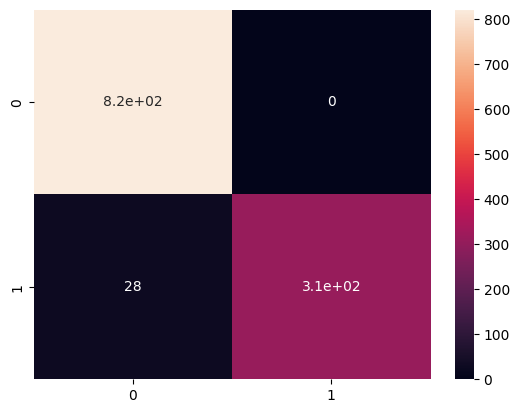

In [ ]:
# confidence graph before undersampling
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
sns.heatmap(confusion_matrix(y_test, pred), annot = True)

In [ ]:
print("\nClassification Report for Undersampled Data:")
print(classification_report(y_test, pred_under))


Classification Report for Undersampled Data:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       821
           1       0.97      0.96      0.97       338

    accuracy                           0.98      1159
   macro avg       0.98      0.97      0.98      1159
weighted avg       0.98      0.98      0.98      1159



<Axes: >

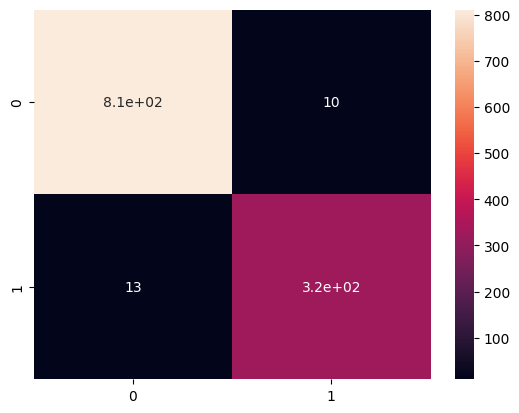

In [ ]:
# confidence graph after undersampling
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
sns.heatmap(confusion_matrix(y_test, pred_under), annot = True)

In [ ]:
#Test
# 1. Define the single email string you want to test
my_email_string = "It was great connecting with you at the Vancouver Tech Summit last week. I really enjoyed our conversation about the challenges of implementing scalable data pipelines. As promised, here is the link to that article I mentioned on real-time data processing that our team found insightful: [Link to a relevant, legitimate article]. Let me know if you're open to continuing our discussion sometime next week."
# 2. Transform the string (wrapped in a list)
# The .transform() method expects a list or other iterable.
my_email_tfidf = tfidf.transform([my_email_string])

# 3. Get the prediction and probability
# We use [0] to get the result for the first (and only) item in our list.
prediction = model.predict(my_email_tfidf)[0]
# Get the probability of the positive class (spam)
probability = model.predict_proba(my_email_tfidf)[0][1]


# 4. Print the result
prediction_label = "Spam" if prediction == 1 else "Not Spam"

print(f"-> Prediction: {prediction_label}")

print(f"-> Prediction: {prediction_label} (Probability of being spam: {probability:.2%})")

-> Prediction: Not Spam
-> Prediction: Not Spam (Probability of being spam: 20.26%)


In [ ]:
print("Done")

Done


In [ ]:
import joblib
from google.colab import files

# --- Save the Trained SVC Model ---
# This line creates the file 'spam_classifier_model.pkl'
model_filename = 'spam_classifier_model.pkl'
joblib.dump(clf_under, model_filename)
print(f"Trained SVC model saved as '{model_filename}'")

# --- Save the TF-IDF Vectorizer ---
# This line creates the file 'tfidf_vectorizer.pkl'
vectorizer_filename = 'tfidf_vectorizer.pkl'
joblib.dump(tfidf, vectorizer_filename)
print(f"TF-IDF vectorizer saved as '{vectorizer_filename}'")

# --- Download both files ---
# These lines will now find the files because you just created them
files.download(model_filename)
files.download(vectorizer_filename)

Trained SVC model saved as 'spam_classifier_model.pkl'
TF-IDF vectorizer saved as 'tfidf_vectorizer.pkl'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>